# 04 — Opportunity Analysis

**Purpose:** convert the validated EDA findings into an explainable merchant-expansion prioritisation.

The result is a research queue for field validation. It is not a prediction of return on investment and does not represent PhonePe policy.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from phonepe_analytics.analysis import ANALYSIS_DIR, shortlist_sensitivity
from phonepe_analytics.metrics import DEFAULT_WEIGHTS, score_opportunities

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
purple = "#5F259F"

district_data = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
latest_period_id = district_data["period_id"].max()
latest_districts = district_data.loc[
    district_data["period_id"].eq(latest_period_id)
].copy()
latest_period = latest_districts["period_label"].iloc[0]

display(
    pd.DataFrame(
        {
            "analysis_period": [latest_period],
            "districts_before_eligibility_rules": [
                len(latest_districts)
            ],
        }
    )
)

,analysis_period,districts_before_eligibility_rules
0,2026-Q2,783


## 1. Define Eligible Districts

Districts must meet all four rules:

| Rule | Threshold | Reason |
|---|---:|---|
| Registered-user scale | At least 100,000 | Reduces unstable ratios from very small user bases |
| Registered-merchant scale | At least 1,000 and greater than zero | Ensures merchant ratios have a meaningful denominator |
| Quarterly transactions | At least 1 million | Keeps the ranking focused on material payment activity |
| Growth history | Transaction QoQ and YoY must be available | Ensures current growth is comparable with prior periods |

In [2]:
eligibility_reasons = pd.DataFrame(
    {
        "eligibility_rule": [
            "Registered users below 100,000",
            "Registered merchants below 1,000 or missing",
            "Quarterly transactions below 1 million",
            "Transaction QoQ or YoY growth missing",
        ],
        "district_count": [
            int(latest_districts["registered_users"].lt(100_000).sum()),
            int(
                latest_districts["registered_merchants"]
                .lt(1_000)
                .fillna(True)
                .sum()
            ),
            int(latest_districts["transaction_count"].lt(1_000_000).sum()),
            int(
                latest_districts[
                    ["transaction_qoq", "transaction_yoy"]
                ]
                .isna()
                .any(axis=1)
                .sum()
            ),
        ],
    }
)
display(eligibility_reasons)

eligible_districts = score_opportunities(latest_districts)
eligibility_summary = pd.DataFrame(
    {
        "districts_before_rules": [len(latest_districts)],
        "eligible_districts": [len(eligible_districts)],
        "eligible_share": [
            len(eligible_districts) / len(latest_districts)
        ],
    }
)
eligibility_summary["eligible_share"] = (
    eligibility_summary["eligible_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(eligibility_summary)

,eligibility_rule,district_count
0,"Registered users below 100,000",103
1,"Registered merchants below 1,000 or missing",71
2,Quarterly transactions below 1 million,68
3,Transaction QoQ or YoY growth missing,0


,districts_before_rules,eligible_districts,eligible_share
0,783,680,86.8%


### Insight

**680 of 783 districts (86.8%)** meet the scale and history rules. Exclusion reasons can overlap, so their counts should not be added. The rules improve comparability; they do not imply that smaller districts have no business potential.

## 2. Opportunity Variables

| Variable | Direction in score | Business meaning | Interpretation limit |
|---|---|---|---|
| Transaction YoY growth | Higher is stronger | Sustained demand momentum compared with the same quarter last year | Growth can be volatile and does not prove future performance |
| Transactions per merchant | Higher is stronger | Payment activity relative to the registered-merchant base | Includes ecosystem activity such as P2P; it is not merchant productivity |
| Users per merchant | Higher is stronger | A relative merchant-registration gap compared with the user base | Registered users and merchants may be inactive |
| Registered users | Higher is stronger | Potential market scale for merchant coverage | Registrations are not active users or addressable population |

The score uses one market-scale variable, one growth variable, one relative penetration variable, and one activity-intensity variable. Average transaction value and transaction amount are excluded to avoid adding more overlapping scale signals.

## 3. Normalisation

In [3]:
percentile_columns = [
    "growth_percentile",
    "intensity_percentile",
    "low_penetration_percentile",
    "scale_percentile",
]

percentile_summary = eligible_districts[
    percentile_columns
].agg(["min", "median", "max"]).T
display(percentile_summary.round(3))

normalized_example = eligible_districts.head(8)[
    ["state", "district", *percentile_columns]
]
display(normalized_example.reset_index(drop=True).round(3))

,min,median,max
growth_percentile,0.0,0.5,1.0
intensity_percentile,0.0,0.5,1.0
low_penetration_percentile,0.0,0.5,1.0
scale_percentile,0.0,0.5,1.0


,state,district,growth_percentile,intensity_percentile,low_penetration_percentile,scale_percentile
0,andhra pradesh,west godavari,0.807,0.996,0.906,0.747
1,telangana,sangareddy,0.879,0.987,0.695,0.892
2,andhra pradesh,dr br ambedkar konaseema,0.909,0.990,0.807,0.641
3,andhra pradesh,east godavari,0.875,0.976,0.717,0.795
4,andhra pradesh,sri potti sriramulu nellore,0.806,0.971,0.728,0.875
5,andhra pradesh,alluri sitharama raju,0.982,0.991,0.972,0.255
6,andhra pradesh,tirupati,0.701,0.981,0.735,0.919
7,andhra pradesh,eluru,0.747,0.988,0.747,0.779


### Insight

Each factor is converted to a percentile between 0 and 1 across the same eligible population. A value of 0.80 means a district ranks at or above roughly 80% of comparable districts on that factor. Percentiles prevent one extreme raw value from dominating the score and keep variables with different units comparable.

## 4. Opportunity Score

In [4]:
weight_labels = {
    "transaction_yoy": "Transaction YoY growth",
    "transactions_per_merchant": "Transactions per merchant",
    "users_per_merchant": "Users per merchant",
    "registered_users": "Registered users",
}
percentile_names = {
    "transaction_yoy": "growth_percentile",
    "transactions_per_merchant": "intensity_percentile",
    "users_per_merchant": "low_penetration_percentile",
    "registered_users": "scale_percentile",
}

weight_table = pd.DataFrame(
    {
        "component": [weight_labels[metric] for metric in DEFAULT_WEIGHTS],
        "percentile_column": [
            percentile_names[metric] for metric in DEFAULT_WEIGHTS
        ],
        "weight": list(DEFAULT_WEIGHTS.values()),
    }
)
display(weight_table)

eligible_districts["score_check"] = 100 * (
    0.30 * eligible_districts["growth_percentile"]
    + 0.25 * eligible_districts["intensity_percentile"]
    + 0.25 * eligible_districts["low_penetration_percentile"]
    + 0.20 * eligible_districts["scale_percentile"]
)
maximum_score_difference = (
    eligible_districts["score_check"]
    - eligible_districts["opportunity_score"]
).abs().max()

score_summary = eligible_districts["opportunity_score"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
)
display(score_summary.round(2).to_frame("opportunity_score"))
print(f"Maximum score-formula difference: {maximum_score_difference:.10f}")

,component,percentile_column,weight
0,Transaction YoY growth,growth_percentile,0.30
1,Transactions per merchant,intensity_percentile,0.25
2,Users per merchant,low_penetration_percentile,0.25
3,Registered users,scale_percentile,0.20


,opportunity_score
count,680.00
mean,50.00
std,14.31
min,11.66
25%,39.72
50%,49.42
75%,60.19
90%,69.77
max,86.68


Maximum score-formula difference: 0.0000000000


### Insight

The default score gives 30% weight to YoY demand growth, 25% each to activity intensity and the relative merchant-registration gap, and 20% to user scale. These are transparent analytical assumptions, not PhonePe policy. A score of 80 represents a weighted relative position; it is not an 80% probability of success.

## 5. Top Opportunity Districts

In [5]:
positive_momentum = (
    eligible_districts["transaction_qoq"].gt(0)
    & eligible_districts["transaction_yoy"].gt(0)
    & eligible_districts["user_qoq"].ge(0)
    & eligible_districts["merchant_qoq"].ge(0)
)
investigation_pool = eligible_districts.loc[
    positive_momentum
].copy()
investigation_pool = investigation_pool.sort_values(
    ["opportunity_score", "state", "district"],
    ascending=[False, True, True],
)
investigation_pool["investigation_rank"] = range(
    1,
    len(investigation_pool) + 1,
)

top_opportunities = investigation_pool.head(10).copy()
top_columns = [
    "investigation_rank",
    "state",
    "district",
    "opportunity_score",
    "registered_users",
    "registered_merchants",
    "transaction_yoy",
    "merchants_per_100k_users",
]
display(top_opportunities[top_columns].round(3))

,investigation_rank,state,district,opportunity_score,registered_users,registered_merchants,transaction_yoy,merchants_per_100k_users
951,1,andhra pradesh,west godavari,86.679,1195968,48583.0,0.305,4062.232
22371,2,telangana,sangareddy,86.274,1849509,102640.0,0.323,5549.581
339,3,andhra pradesh,dr br ambedkar konaseema,84.993,930577,45653.0,0.330,4905.881
373,4,andhra pradesh,east godavari,84.492,1370485,74989.0,0.322,5471.713
747,5,andhra pradesh,sri potti sriramulu nellore,84.116,1729942,93583.0,0.305,5409.603
135,6,andhra pradesh,alluri sitharama raju,83.645,411684,11247.0,0.379,2731.950
849,7,andhra pradesh,tirupati,82.305,2219362,118910.0,0.282,5357.846
407,8,andhra pradesh,eluru,81.355,1279217,67639.0,0.292,5287.531
10743,9,karnataka,mandya,81.082,975953,41069.0,0.282,4208.092
10539,10,karnataka,hassan,80.265,1110612,42357.0,0.264,3813.843


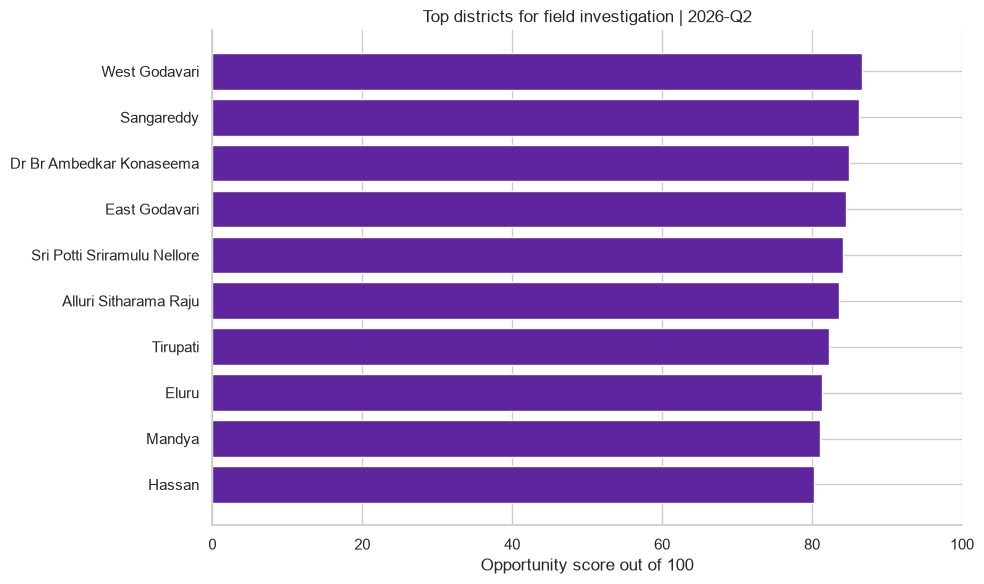

In [6]:
chart_data = top_opportunities.sort_values("opportunity_score")

fig, axis = plt.subplots(figsize=(10, 6))
axis.barh(
    chart_data["district"].str.title(),
    chart_data["opportunity_score"],
    color=purple,
)
axis.set_xlim(0, 100)
axis.set_title(f"Top districts for field investigation | {latest_period}")
axis.set_xlabel("Opportunity score out of 100")
axis.set_ylabel("")
fig.tight_layout()
plt.show()

### Insight

**West Godavari** and **Sangareddy** lead the positive-momentum research queue. **7 of the top 10** are in **Andhra Pradesh**, showing a strong regional concentration that should be checked for common geography, source definitions, and local operating conditions before concentrating spend.

## 6. Sensitivity Analysis

In [7]:
sensitivity_summary, sensitivity_ranking = shortlist_sensitivity(
    investigation_pool
)
display(sensitivity_summary)

sensitivity_columns = [
    "state",
    "district",
    "opportunity_score",
    "equal_weight_shortlist_rank",
    "no_intensity_shortlist_rank",
    "recommendation",
]
display(sensitivity_ranking[sensitivity_columns].round(3))

stable_candidates = sensitivity_ranking.loc[
    sensitivity_ranking["no_intensity_shortlist_rank"].le(10)
].copy()

,scenario,top10_overlap
0,opportunity,10
1,equal_weight,9
2,no_intensity,6


,state,district,opportunity_score,equal_weight_shortlist_rank,no_intensity_shortlist_rank,recommendation
951,andhra pradesh,west godavari,86.679,1,2,Priority field validation
22371,telangana,sangareddy,86.274,2,4,Priority field validation
339,andhra pradesh,dr br ambedkar konaseema,84.993,5,6,Priority field validation
373,andhra pradesh,east godavari,84.492,4,7,Priority field validation
747,andhra pradesh,sri potti sriramulu nellore,84.116,3,9,Priority field validation
135,andhra pradesh,alluri sitharama raju,83.645,12,8,Priority field validation
849,andhra pradesh,tirupati,82.305,6,15,Investigate; sensitive to intensity weighting
407,andhra pradesh,eluru,81.355,7,20,Investigate; sensitive to intensity weighting
10743,karnataka,mandya,81.082,10,19,Investigate; sensitive to intensity weighting
10539,karnataka,hassan,80.265,9,22,Investigate; sensitive to intensity weighting


### Insight

The equal-weight scenario retains **9 of the default top 10**, while the no-intensity scenario retains **6**. The six stable districts are **West Godavari, Sangareddy, Dr Br Ambedkar Konaseema, East Godavari, Sri Potti Sriramulu Nellore, Alluri Sitharama Raju**. Their rankings depend less on the transactions-per-merchant proxy, so they deserve greater confidence for field validation than districts whose position changes sharply.

## 7. Business Segmentation

Segments are assigned in this order:

| Segment | Rule | Intended action |
|---|---|---|
| **EXPAND** | Opportunity percentile ≥ 75th and penetration-gap percentile ≥ 50th | Investigate merchant-acquisition potential |
| **DEFEND** | Scale percentile ≥ 75th and penetration-gap percentile < 50th | Protect and activate an already large, denser network |
| **DEVELOP** | Opportunity percentile ≥ 50th after the first two rules | Build demand and coverage selectively |
| **MONITOR** | All remaining eligible districts | Track before allocating acquisition effort |

The labels describe relative analytical positions. They do not establish market saturation or prescribe a budget.

In [8]:
segment_order = ["EXPAND", "DEFEND", "DEVELOP", "MONITOR"]
segment_summary = (
    eligible_districts.groupby("business_segment")
    .agg(
        district_count=("district", "size"),
        median_score=("opportunity_score", "median"),
        median_transaction_yoy=("transaction_yoy", "median"),
        median_registered_users=("registered_users", "median"),
        median_users_per_merchant=("users_per_merchant", "median"),
    )
    .reindex(segment_order)
)
display(segment_summary.round(3))

,district_count,median_score,median_transaction_yoy,median_registered_users,median_users_per_merchant
business_segment,,,,,
EXPAND,132,68.678,0.280,850884.5,18.910
DEFEND,121,46.495,0.245,1843408.0,12.588
DEVELOP,154,54.750,0.258,570962.5,16.948
MONITOR,273,39.411,0.226,528271.0,14.479


### Insight

The eligible population contains **132 EXPAND**, **121 DEFEND**, **154 DEVELOP**, and **273 MONITOR** districts. Segmentation translates relative scores into distinct research actions while preserving the underlying evidence for review.

## 8. Final Recommendations

In [9]:
recommendation_columns = [
    "state",
    "district",
    "registered_users",
    "registered_merchants",
    "transaction_yoy",
    "merchants_per_100k_users",
    "opportunity_score",
    "equal_weight_shortlist_rank",
    "no_intensity_shortlist_rank",
]
display(stable_candidates[recommendation_columns].round(3))

,state,district,registered_users,registered_merchants,transaction_yoy,merchants_per_100k_users,opportunity_score,equal_weight_shortlist_rank,no_intensity_shortlist_rank
951,andhra pradesh,west godavari,1195968,48583.0,0.305,4062.232,86.679,1,2
22371,telangana,sangareddy,1849509,102640.0,0.323,5549.581,86.274,2,4
339,andhra pradesh,dr br ambedkar konaseema,930577,45653.0,0.330,4905.881,84.993,5,6
373,andhra pradesh,east godavari,1370485,74989.0,0.322,5471.713,84.492,4,7
747,andhra pradesh,sri potti sriramulu nellore,1729942,93583.0,0.305,5409.603,84.116,3,9
135,andhra pradesh,alluri sitharama raju,411684,11247.0,0.379,2731.950,83.645,12,8


### Recommended Field-Validation Priorities

        - **West Godavari, Andhra Pradesh** — 1,195,968 registered users, 30.5% YoY transaction growth (above the eligible median), and 4,062 merchants per 100K users (below the eligible median).
- **Sangareddy, Telangana** — 1,849,509 registered users, 32.3% YoY transaction growth (above the eligible median), and 5,550 merchants per 100K users (below the eligible median).
- **Dr Br Ambedkar Konaseema, Andhra Pradesh** — 930,577 registered users, 33.0% YoY transaction growth (above the eligible median), and 4,906 merchants per 100K users (below the eligible median).
- **East Godavari, Andhra Pradesh** — 1,370,485 registered users, 32.2% YoY transaction growth (above the eligible median), and 5,472 merchants per 100K users (below the eligible median).
- **Sri Potti Sriramulu Nellore, Andhra Pradesh** — 1,729,942 registered users, 30.5% YoY transaction growth (above the eligible median), and 5,410 merchants per 100K users (below the eligible median).
- **Alluri Sitharama Raju, Andhra Pradesh** — 411,684 registered users, 37.9% YoY transaction growth (above the eligible median), and 2,732 merchants per 100K users (below the eligible median).

        These districts combine market scale, above-median demand growth, and lower relative merchant penetration across more than one weighting choice. PhonePe should investigate active acceptance, local merchant categories, competitor coverage, acquisition cost, and 30-day merchant activation before committing expansion spend.

## 9. Limitations

- **Registered users are not necessarily active users.** The user base may overstate currently addressable demand.
- **Registered merchants are not necessarily active merchants.** Registration density does not measure recent payment acceptance.
- **Total transactions are not merchant-only transactions.** District activity includes ecosystem transactions and cannot be treated as merchant sales or productivity.
- **Aggregate data cannot prove causality.** The analysis cannot show that adding merchants will cause transaction growth.
- **The ranking is prioritisation, not proof of ROI.** Weights and eligibility thresholds are analytical assumptions and must be tested with field evidence and operating costs.

The final decision is to begin field validation with the six sensitivity-stable districts, then use active-merchant, category, cost, and pilot-performance data to decide whether expansion is commercially justified.